IMPORTS

In [2]:
%pip install torch -q
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


LOAD DATA

In [3]:

data_path = "nasa_power_daily_raw.csv"

df = pd.read_csv(data_path)

print(df.shape)
print(df.head())

(12785, 10)
     city  latitude  longitude        date   T2M  T2M_MAX  T2M_MIN  \
0  London   51.5074    -0.1278  2016-01-01  5.17     7.09     2.47   
1  London   51.5074    -0.1278  2016-01-02  8.58     9.52     6.72   
2  London   51.5074    -0.1278  2016-01-03  6.55     8.29     4.25   
3  London   51.5074    -0.1278  2016-01-04  7.05     8.49     5.85   
4  London   51.5074    -0.1278  2016-01-05  7.32     9.28     5.91   

   PRECTOTCORR   RH2M  WS2M  
0         5.18  94.66  3.94  
1         3.50  95.32  5.20  
2        11.59  96.01  4.50  
3         6.88  95.86  3.68  
4         3.12  96.07  2.04  


In [4]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['city', 'date']).reset_index(drop=True)

HANDLE NULLS (Time-Series Safe)

In [5]:
print("Total null values per column:")
print(df.isnull().sum())

print("\nTotal rows:", len(df))

Total null values per column:
city           0
latitude       0
longitude      0
date           0
T2M            0
T2M_MAX        0
T2M_MIN        0
PRECTOTCORR    0
RH2M           0
WS2M           0
dtype: int64

Total rows: 12785


In [6]:
df = df.groupby('city').apply(lambda x: x.ffill()).reset_index(drop=True)
df = df.groupby('city').apply(lambda x: x.bfill()).reset_index(drop=True)
df = df.dropna().reset_index(drop=True)

print("After null handling:", df.shape)

After null handling: (12785, 10)


C:\Users\ravik\AppData\Local\Temp\ipykernel_3084\3845622878.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('city').apply(lambda x: x.ffill()).reset_index(drop=True)
C:\Users\ravik\AppData\Local\Temp\ipykernel_3084\3845622878.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('city').apply(lambda x: x.bfill()).reset_index(drop=True)


FEATURE ENGINEERING

In [7]:
df_numeric = df.select_dtypes(include=[np.number]).copy()

In [8]:
rolling_window = 7

for col in df_numeric.columns:
    df_numeric[f"{col}_roll_mean"] = df_numeric[col].rolling(rolling_window).mean()
    df_numeric[f"{col}_roll_std"] = df_numeric[col].rolling(rolling_window).std()

df_numeric = df_numeric.dropna().reset_index(drop=True)

TRAIN / TEST SPLIT

In [9]:
X = df_numeric.values

split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train = X[:split_index]
X_test  = X[split_index:]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (10223, 24)
Test: (2556, 24)


SCALING (FIT ON TRAIN ONLY)

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

CREATE SEQUENCES

In [11]:
WINDOW_SIZE = 60

def create_sequences(data, window):
    sequences = []
    for i in range(len(data) - window):
        sequences.append(data[i:i+window])
    return np.array(sequences)

X_train_seq = create_sequences(X_train_scaled, WINDOW_SIZE)
X_test_seq  = create_sequences(X_test_scaled, WINDOW_SIZE)

print("Train seq:", X_train_seq.shape)
print("Test seq:", X_test_seq.shape)

Train seq: (10163, 60, 24)
Test seq: (2496, 60, 24)


CONVERT TO TENSORS

In [12]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test_seq, dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

LSTM AUTOENCODER

In [14]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden_size=64, latent_dim=32):
        super().__init__()

        self.encoder = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc_enc = nn.Linear(hidden_size, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, hidden_size)

        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=n_features,
            batch_first=True
        )

    def forward(self, x):
        encoded_seq, _ = self.encoder(x)
        last_hidden = encoded_seq[:, -1, :]

        latent = torch.relu(self.fc_enc(last_hidden))
        decoded_input = torch.relu(self.fc_dec(latent)).unsqueeze(1)
        decoded_input = decoded_input.repeat(1, x.size(1), 1)

        reconstructed, _ = self.decoder(decoded_input)
        return reconstructed

INITIALIZE MODEL

In [15]:
n_features = X_train_seq.shape[2]

model = LSTMAutoencoder(n_features).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

TRAIN MODEL

In [16]:
EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)

        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_x)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss/len(train_loader):.6f}")






Epoch 1/30, Loss: 0.711820
Epoch 2/30, Loss: 0.583431
Epoch 3/30, Loss: 0.565271
Epoch 4/30, Loss: 0.551880
Epoch 5/30, Loss: 0.539851
Epoch 6/30, Loss: 0.531767
Epoch 7/30, Loss: 0.526106
Epoch 8/30, Loss: 0.521926
Epoch 9/30, Loss: 0.519070
Epoch 10/30, Loss: 0.515899
Epoch 11/30, Loss: 0.514337
Epoch 12/30, Loss: 0.511963
Epoch 13/30, Loss: 0.510580
Epoch 14/30, Loss: 0.509616
Epoch 15/30, Loss: 0.507911
Epoch 16/30, Loss: 0.507375
Epoch 17/30, Loss: 0.505164
Epoch 18/30, Loss: 0.503255
Epoch 19/30, Loss: 0.501983
Epoch 20/30, Loss: 0.500588
Epoch 21/30, Loss: 0.500009
Epoch 22/30, Loss: 0.498612
Epoch 23/30, Loss: 0.497453
Epoch 24/30, Loss: 0.495840
Epoch 25/30, Loss: 0.495049
Epoch 26/30, Loss: 0.493897
Epoch 27/30, Loss: 0.492469
Epoch 28/30, Loss: 0.492238
Epoch 29/30, Loss: 0.491163
Epoch 30/30, Loss: 0.490976


RECONSTRUCTION ERROR

In [17]:
model.eval()

with torch.no_grad():
    train_recon = model(X_train_tensor).cpu().numpy()
    test_recon  = model(X_test_tensor).cpu().numpy()

train_loss = np.mean((X_train_seq - train_recon)**2, axis=(1,2))
test_loss  = np.mean((X_test_seq - test_recon)**2, axis=(1,2))

THRESHOLD (Statistical)

In [18]:
threshold = train_loss.mean() + 3 * train_loss.std()

train_preds = (train_loss > threshold).astype(int)
test_preds  = (test_loss > threshold).astype(int)

print("Train anomaly %:", round(train_preds.mean()*100,2))
print("Test anomaly %:", round(test_preds.mean()*100,2))

Train anomaly %: 1.21
Test anomaly %: 0.16


METRICS

In [19]:
stability_gap = abs(train_preds.mean() - test_preds.mean())
print("Stability Gap:", round(stability_gap*100,2), "%")

Stability Gap: 1.05 %


In [21]:
normal_scores = train_loss[train_preds == 0]
anomaly_scores = train_loss[train_preds == 1]

separation_score = anomaly_scores.mean() - normal_scores.mean()
print("Separation Score:", round(separation_score,4))

Separation Score: 5.3684


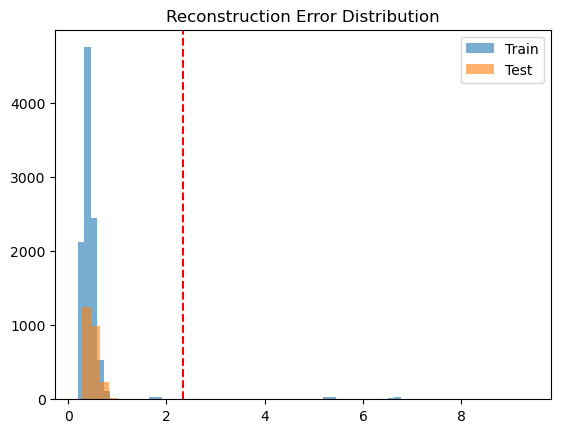

In [22]:
plt.hist(train_loss, bins=50, alpha=0.6, label="Train")
plt.hist(test_loss, bins=50, alpha=0.6, label="Test")
plt.axvline(threshold, color='red', linestyle='--')
plt.legend()
plt.title("Reconstruction Error Distribution")
plt.show()

In [23]:
print("\n----- Final Model Evaluation -----")
print("Train anomaly %:", round(train_preds.mean()*100,2))
print("Test anomaly %:", round(test_preds.mean()*100,2))
print("Stability Gap %:", round(stability_gap*100,2))
print("Separation Score:", round(separation_score,4))


----- Final Model Evaluation -----
Train anomaly %: 1.21
Test anomaly %: 0.16
Stability Gap %: 1.05
Separation Score: 5.3684
